# QA: events.tsv / BOLD run alignment check

Some participants have BOLD runs whose events.tsv is **missing or empty** -- every BOLD run
usually does have *some* events.tsv file on disk, but for a run that was started then aborted
almost immediately, that file can exist with no usable trials in it (just a header, or rows with
no real onsets) rather than being absent outright. See e.g. sub-SSP001, which has BOLD run-01/02/03
and an events.tsv for all three run numbers, but run-02's events.tsv has zero usable 'sound' trials
-- effectively undocumented, the same as if the file didn't exist.

The existing pipeline (`drop_empty_event_runs` in `univariate_first-level.py` /
`GLMsingle_first-level.py`) handles this by simply dropping any BOLD run whose events.tsv has no
usable trials, on the assumption that run's behavioral log is genuinely missing/empty (aborted,
undocumented run). But it's possible instead that the behavioral log for that run exists and was
just filed under the *wrong* run number -- e.g. that the events.tsv labeled `run-03` actually
reflects what happened during the `run-02` scan, and whatever happened during the real `run-03`
scan is what left behind the empty file.

BOLD run numbers are assigned by DICOM acquisition order (`dicom_conversion/heuristic.py`),
completely independently of however events.tsv files get their own run numbers (that conversion
step isn't in this repo) -- so there's no structural guarantee the two numbering schemes agree,
and it needs to be checked empirically per subject.

**This notebook's test**: for every subject with an "orphan" BOLD run (a BOLD run with no
*usable* events.tsv of its own -- missing file or empty file, either counts), fit a single-run GLM
using that subject's *other*, usable events.tsv file(s) against (a) their own officially-matching
BOLD run, and (b) the orphan BOLD run -- then compare the `sound` contrast (broadest, most robust
response in a single run) between the two fits. A correctly time-locked design should explain the
BOLD signal far better than a shifted one, so if `events(run-03)` fits `BOLD(run-02)` about as well
as -- or better than -- it fits its own `BOLD(run-03)`, that is real evidence of mislabeling, not
just a hunch.

This notebook is diagnostic only -- it does not relabel, rename, or move any file, and it never
overwrites first-level outputs used by the rest of the pipeline (it writes to its own
`qa_events-bold-alignment` output directory). Read the plots and summary table and decide, per
subject, whether to fix a mislabeled file by hand and re-run the standard pipeline for that
subject.

## Imports and definitions

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from glob import glob

from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.fmriprep import load_confounds_strategy
from nilearn.image import resample_to_img, binarize_img
from nilearn import plotting

In [2]:
task_label = 'badaga'
space_label = 'MNI152NLin2009cAsym'
fwhm = 6.0
# NOTE: t_r/slice_time_ref are intentionally NOT passed to first_level_from_bids below (both left
# at their default None), matching univariate_first-level.py -- both are inferred directly from
# each run's own bold.json metadata rather than hand-specified.

bidsroot = os.path.join('/ix1/bchandrasekaran/krs228/data/',
                        'SSP/',
                        'data_bids')
fmriprep_dir = os.path.join(bidsroot, 'derivatives', 'fmriprep-23.2.1')
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')
masks_dir = os.path.join(nilearn_dir, 'masks')

qa_out_dir = os.path.join(nilearn_dir, 'qa_events-bold-alignment')
os.makedirs(qa_out_dir, exist_ok=True)

# ROIs used for the quantitative "how strong is the auditory response" summary metric -- primary
# auditory cortex + STG, bilaterally (a subset of CORTICAL_ROI_LIST in group_level_all_ROI.ipynb),
# chosen because the 'sound' contrast should be strongest here in any correctly-aligned single run.
AUDITORY_ROI_LIST = ['L-HG', 'L-STGa', 'L-STGp', 'R-HG', 'R-STGa', 'R-STGp']

CUT_COORDS = {'sound': [-49, -22, 8], 'response': [-32, -22, 58]}

## Find subjects with events.tsv / BOLD run mismatches

Lists raw BOLD run numbers vs. events.tsv run numbers directly from the BIDS raw dataset (not the
fMRIPrep derivatives -- events.tsv only ever lives in the raw dataset). A BOLD run is flagged as
"orphan" if it has no *usable* events.tsv of its own -- checking file existence alone isn't enough,
since a run that was started then aborted almost immediately can still have an events.tsv on disk
with zero usable trials in it (same criterion `drop_empty_event_runs` already uses elsewhere in
this pipeline: at least one row with `trial_type == 'sound'`). Also reports each run's volume
count as a cheap, complementary check: an orphan run that's *much shorter* than the subject's
other runs is more consistent with a genuinely truncated/aborted run (supporting the current
drop-it behavior); an orphan run that's a normal, full length is more suspicious (more consistent
with mislabeling, worth the full GLM-fit comparison below).

In [3]:
RUN_RE = re.compile(r'_run-(\d+)_')


def _fpaths_by_run(fpaths):
    """Map each BIDS-style file's run number (int) to its fullpath -- assumes exactly one file
    per run number in the given list (true for both BOLD and events.tsv globs here). Returning a
    dict (not a list of ints) keeps each run number paired with the exact file it came from, so
    a later per-file content check can't drift out of sync with a separately-sorted number list.
    """
    by_run = {}
    for fpath in fpaths:
        match = RUN_RE.search(os.path.basename(fpath))
        if match:
            by_run[int(match.group(1))] = fpath
    return by_run


def _has_usable_sound_trials(events_fpath):
    """Same 'usable' criterion as drop_empty_event_runs in univariate_first-level.py /
    GLMsingle_first-level.py: at least one row with trial_type == 'sound'. An events.tsv can exist
    on disk (pass a naive file-existence check) and still be empty/unusable -- e.g. a run that was
    started then aborted almost immediately logs a near-empty events.tsv, not a missing one, so
    this has to actually open and check the file rather than just globbing for it.
    """
    try:
        events_df = pd.read_csv(events_fpath, sep='\t')
    except pd.errors.EmptyDataError:
        return False
    return 'trial_type' in events_df.columns and (events_df['trial_type'] == 'sound').any()


def find_run_mismatches(bidsroot, task_label, sub_list):
    """For each subject, list raw BOLD run numbers vs. *usable* events.tsv run numbers, flag any
    BOLD run with no usable events.tsv ('orphan' runs -- missing file or empty file, either
    counts), and record each BOLD run's volume count. Returns {sub_id: {'bold_runs': [...],
    'usable_event_runs': [...], 'empty_event_runs': [...], 'orphan_bold_runs': [...],
    'n_volumes_by_run': {run: n}}} for every subject (including those with no mismatch, so the
    caller can see the full picture). 'empty_event_runs' are runs whose events.tsv exists but has
    no usable trials -- kept separate from a run with no events.tsv file at all purely for
    reporting; both count the same way as 'orphan' from the BOLD run's perspective.
    """
    mismatches = {}
    for sub_id in sub_list:
        func_dir = os.path.join(bidsroot, sub_id, 'func')
        bold_by_run = _fpaths_by_run(
            glob(os.path.join(func_dir, f'{sub_id}_task-{task_label}_run-*_bold.nii.gz')))
        events_by_run = _fpaths_by_run(
            glob(os.path.join(func_dir, f'{sub_id}_task-{task_label}_run-*_events.tsv')))

        bold_runs = sorted(bold_by_run)
        usable_event_runs = sorted(r for r, fpath in events_by_run.items()
                                   if _has_usable_sound_trials(fpath))
        empty_event_runs = sorted(r for r, fpath in events_by_run.items()
                                  if r not in usable_event_runs)
        orphan_bold_runs = [r for r in bold_runs if r not in usable_event_runs]

        # nib.load is lazy -- .shape only reads the header, not the full 4D array
        n_volumes_by_run = {run: nib.load(fpath).shape[-1] for run, fpath in bold_by_run.items()}

        mismatches[sub_id] = {
            'bold_runs': bold_runs,
            'usable_event_runs': usable_event_runs,
            'empty_event_runs': empty_event_runs,
            'orphan_bold_runs': orphan_bold_runs,
            'n_volumes_by_run': n_volumes_by_run,
        }
    return mismatches

In [4]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')
sub_list = sorted(participants_df.participant_id.tolist())

mismatch_dict = find_run_mismatches(bidsroot, task_label, sub_list)

flagged_subs = {sub_id: info for sub_id, info in mismatch_dict.items() if info['orphan_bold_runs']}

print(f'{len(flagged_subs)} of {len(sub_list)} subjects have at least one orphan BOLD run '
     '(a BOLD run with no usable events.tsv):')
for sub_id, info in flagged_subs.items():
    missing_file = [r for r in info['orphan_bold_runs'] if r not in info['empty_event_runs']]
    print(f"  {sub_id}: BOLD runs {info['bold_runs']}, usable events runs {info['usable_event_runs']}, "
         f"orphan BOLD run(s) {info['orphan_bold_runs']} "
         f"(events file present-but-empty for run(s) {info['empty_event_runs']}, "
         f"no events file at all for run(s) {missing_file}), "
         f"volumes-by-run {info['n_volumes_by_run']}")

4 of 57 subjects have at least one orphan BOLD run (a BOLD run with no usable events.tsv):
  sub-SSP001: BOLD runs [1, 2, 3], usable events runs [1, 3], orphan BOLD run(s) [2] (events file present-but-empty for run(s) [2], no events file at all for run(s) []), volumes-by-run {3: 184, 1: 184, 2: 184}
  sub-SSP002: BOLD runs [1, 2, 3], usable events runs [1, 3], orphan BOLD run(s) [2] (events file present-but-empty for run(s) [2], no events file at all for run(s) []), volumes-by-run {2: 184, 1: 184, 3: 184}
  sub-SSP005: BOLD runs [1, 2, 3], usable events runs [1, 3], orphan BOLD run(s) [2] (events file present-but-empty for run(s) [2], no events file at all for run(s) []), volumes-by-run {2: 184, 1: 184, 3: 184}
  sub-SSP012: BOLD runs [1, 2, 3], usable events runs [1, 3], orphan BOLD run(s) [2] (events file present-but-empty for run(s) [2], no events file at all for run(s) []), volumes-by-run {3: 184, 1: 184, 2: 184}


## Single-run GLM fitting

`fit_single_run_glm` fits sub_id's events.tsv for `events_run` against the BOLD data for
`bold_run` -- which may be a *different* run number; that mismatch is the whole point of this
check. `first_level_from_bids` can't be used directly to load an orphan run's BOLD image on its
own (it requires an exact events.tsv-count match per subject-level call and raises before
returning anything for a run with zero events.tsv), so `bold_run`'s own preprocessed image path
is instead derived by substituting the run number into `events_run`'s own discovered path
(fMRIPrep's naming only differs in the run entity), and its confounds are loaded directly via
`load_confounds_strategy`, the same way the main pipeline does.

In [5]:
def _collapse_to_sound_events(run_events):
    """Same trial_type construction as update_events(event_type='sound') in
    univariate_first-level.py -- collapses per-trial suffixes down to the base 'sound'/'response'
    labels used by the contrast_list=['sound', 'response'] convention. Duplicated here rather than
    imported since this notebook intentionally bypasses the rest of that pipeline's
    multi-run/matched-events assumptions.
    """
    run_events = run_events.copy()
    run_events['trial_type'] = run_events.trial_type.str.split('_', expand=True)[0]
    return run_events


def fit_single_run_glm(bidsroot, fmriprep_dir, task_label, space_label, sub_id, fwhm,
                       events_run, bold_run):
    """Fit a single-run GLM using sub_id's events.tsv for `events_run` against the BOLD data for
    `bold_run`. Returns {contrast_label: z_map} for whichever of ['sound', 'response'] actually
    appear as trial types in this events file.
    """
    # first_level_from_bids's sub_labels must be the BARE label (no 'sub-' prefix / hyphen --
    # it fails a hard alphanumeric check otherwise), unlike sub_id everywhere else in this
    # notebook, which is the full 'sub-XXX' directory-name form (matching participants.tsv).
    bare_sub_label = sub_id.removeprefix('sub-')
    models, models_run_imgs, raw_models_events, _ = first_level_from_bids(
        bidsroot, task_label, space_label=space_label, sub_labels=[bare_sub_label],
        img_filters=[('run', f'{events_run:02d}')],
        smoothing_fwhm=fwhm, derivatives_folder=fmriprep_dir,
        slice_time_ref=None, minimize_memory=False,
    )
    model = models[0]
    events_own_bold_img = models_run_imgs[0]
    events_df = raw_models_events[0]
    # single-run subject/filter combos return bare values, not length-1 lists (same
    # normalization needed elsewhere in this pipeline for the same reason)
    if isinstance(events_own_bold_img, list):
        events_own_bold_img = events_own_bold_img[0]
    if isinstance(events_df, list):
        events_df = events_df[0]

    events_df = _collapse_to_sound_events(events_df)

    if bold_run == events_run:
        bold_img = events_own_bold_img
    else:
        old_token = f'_run-{events_run:02d}_'
        new_token = f'_run-{bold_run:02d}_'
        if old_token not in events_own_bold_img:
            raise ValueError(
                f"Expected {old_token!r} in the discovered BOLD path {events_own_bold_img!r} -- "
                "naming convention assumption broke, can't safely derive the orphan run's path."
            )
        bold_img = events_own_bold_img.replace(old_token, new_token)
        if not os.path.exists(bold_img):
            raise FileNotFoundError(
                f'Expected {sub_id} run-{bold_run:02d} preprocessed BOLD at {bold_img} but it '
                'does not exist.'
            )

    print(f'  fitting {sub_id}: events(run-{events_run:02d}) x BOLD(run-{bold_run:02d})')
    confounds_df, sample_mask = load_confounds_strategy(
        img_files=bold_img, denoise_strategy='scrubbing', fd_threshold=0.9, std_dvars_threshold=1.5)

    model.fit([bold_img], [events_df], [confounds_df], sample_masks=[sample_mask])

    z_maps = {}
    for contrast_label in ['sound', 'response']:
        if contrast_label not in events_df['trial_type'].unique():
            print(f'    no {contrast_label!r} trials in events(run-{events_run:02d}) -- skipping.')
            continue
        z_maps[contrast_label] = model.compute_contrast(contrast_label, output_type='z_score')

    return z_maps

## Quantitative summary + plotting

In [6]:
def _auditory_union_mask(sub_id, roi_list, masks_dir, space_label, ref_img):
    """Union of per-ROI masks (resampled to ref_img's grid) as a single boolean array -- used to
    summarize the 'sound' contrast within a robust, subject-specific auditory ROI, matching the
    per-subject masks already used throughout this pipeline (group_level_all_ROI.ipynb's
    mask_stat_maps). Returns None if no ROI masks were found for this subject.
    """
    union = None
    for roi in roi_list:
        matches = glob(os.path.join(masks_dir, sub_id, f'space-{space_label}', 'masks-dseg', f'*{roi}*.nii.gz'))
        if not matches:
            continue
        mask_img = resample_to_img(matches[0], ref_img, interpolation='nearest',
                                   force_resample=True, copy_header=True)
        mask_img = binarize_img(mask_img, two_sided=False, copy_header=True)
        mask_data = mask_img.get_fdata().astype(bool)
        union = mask_data if union is None else (union | mask_data)
    return union


def summarize_zmap(z_map, sub_id, roi_list, masks_dir, space_label):
    """Scalar summary of a single-run z-map's 'sound'-response strength: whole-brain peak |z|,
    and mean z within a bilateral auditory-cortex ROI union. A correctly time-locked fit should
    show a strong, focal positive mean_auditory_roi_z; a mismatched fit should look noise-like
    (near zero, or driven only by a peak_abs_z outlier voxel elsewhere).
    """
    z_data = z_map.get_fdata()
    peak_abs_z = float(np.nanmax(np.abs(z_data)))

    union_mask = _auditory_union_mask(sub_id, roi_list, masks_dir, space_label, z_map)
    if union_mask is None or union_mask.sum() == 0:
        mean_roi_z = np.nan
    else:
        mean_roi_z = float(np.nanmean(z_data[union_mask]))

    return {'peak_abs_z': peak_abs_z, 'mean_auditory_roi_z': mean_roi_z}


def plot_fit_comparison(sub_id, fits, contrast_label='sound', out_dir=None):
    panels = [f for f in fits if contrast_label in f['z_maps']]
    if not panels:
        print(f'No {contrast_label!r} fits available for {sub_id} -- skipping plot.')
        return None

    vmax = max(np.nanmax(np.abs(f['z_maps'][contrast_label].get_fdata())) for f in panels)

    # one row per events.tsv file, columns = that file's pairings (official/candidate)
    events_runs = sorted({f['events_run'] for f in panels})
    rows = [[f for f in panels if f['events_run'] == er] for er in events_runs]
    n_rows = len(rows)
    n_cols = max(len(row) for row in rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3 * n_rows), dpi=300,
                             squeeze=False)
    fig.suptitle(f'{sub_id} -- contrast-{contrast_label}', fontsize='large')

    for row_axes, row_fits in zip(axes, rows):
        for ax, f in zip(row_axes, row_fits):
            title = (f"{f['label']}: events(run-{f['events_run']:02d}) x "
                    f"BOLD(run-{f['bold_run']:02d})")
            plotting.plot_stat_map(f['z_maps'][contrast_label], threshold=1.96, vmax=vmax,
                                   cut_coords=CUT_COORDS.get(contrast_label),
                                   axes=ax, title=title, colorbar=True)
        for ax in row_axes[len(row_fits):]:  # hide unused axes if a row is short a panel
            ax.axis('off')

    fig.tight_layout()
    if out_dir is not None:
        out_fpath = os.path.join(out_dir, f'{sub_id}_contrast-{contrast_label}_alignment-qa.png')
        fig.savefig(out_fpath, bbox_inches='tight')
        print(f'Saved {out_fpath}')
    return fig


## Run the comparison

For every flagged subject and every orphan BOLD run, fits each of the subject's *usable*
events.tsv files against (a) its own officially-matching BOLD run ("official" -- doubles as this
subject's own reference for what a correctly-aligned single run looks like) and (b) the orphan
BOLD run ("candidate"). A subject with more than one usable events.tsv file gets more than one
official reference "for free," which helps calibrate what a normal peak_abs_z /
mean_auditory_roi_z range looks like for this specific subject before judging the candidate fit.


=== sub-SSP001: orphan BOLD run-02 (184 volumes; other runs: {3: 184, 1: 184}) ===
  fitting sub-SSP001: events(run-01) x BOLD(run-01)


/scratch/slurm-10738944/ipykernel_4093767/1646583887.py:62: UserWarning: The following unexpected columns in events data will be ignored: stim_file, correct_key, speaker, Unnamed: 0, noise_level, response_key, syllable, response_time
  model.fit([bold_img], [events_df], [confounds_df], sample_masks=[sample_mask])


  fitting sub-SSP001: events(run-01) x BOLD(run-02)


/scratch/slurm-10738944/ipykernel_4093767/1646583887.py:62: UserWarning: The following unexpected columns in events data will be ignored: stim_file, correct_key, speaker, Unnamed: 0, noise_level, response_key, syllable, response_time
  model.fit([bold_img], [events_df], [confounds_df], sample_masks=[sample_mask])


  fitting sub-SSP001: events(run-03) x BOLD(run-03)


...

/scratch/slurm-10738944/ipykernel_4093767/1646583887.py:62: UserWarning: The following unexpected columns in events data will be ignored: stim_file, correct_key, speaker, Unnamed: 0, noise_level, response_key, syllable, response_time
  model.fit([bold_img], [events_df], [confounds_df], sample_masks=[sample_mask])


  fitting sub-SSP012: events(run-03) x BOLD(run-02)


/scratch/slurm-10738944/ipykernel_4093767/1646583887.py:62: UserWarning: The following unexpected columns in events data will be ignored: stim_file, correct_key, speaker, Unnamed: 0, noise_level, response_key, syllable, response_time
  model.fit([bold_img], [events_df], [confounds_df], sample_masks=[sample_mask])
/scratch/slurm-10738944/ipykernel_4093767/3758868199.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /ix1/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/qa_events-bold-alignment/sub-SSP012_contrast-sound_alignment-qa.png


,sub_id,orphan_bold_run,events_run,bold_run,pairing,contrast,peak_abs_z,mean_auditory_roi_z
0,sub-SSP001,2,1,1,official,sound,5.291964,1.553762
1,sub-SSP001,2,1,1,official,response,4.496635,-0.887750
2,sub-SSP001,2,1,2,candidate,sound,5.140168,-0.101867
3,sub-SSP001,2,1,2,candidate,response,4.706709,0.321680
4,sub-SSP001,2,3,3,official,sound,6.143249,1.270427
5,sub-SSP001,2,3,3,official,response,5.240024,-1.095747
6,sub-SSP001,2,3,2,candidate,sound,5.017069,0.043220
7,sub-SSP001,2,3,2,candidate,response,4.490260,0.173719
8,sub-SSP002,2,1,1,official,sound,5.612242,1.523989
9,sub-SSP002,2,1,1,official,response,5.564920,-1.352645


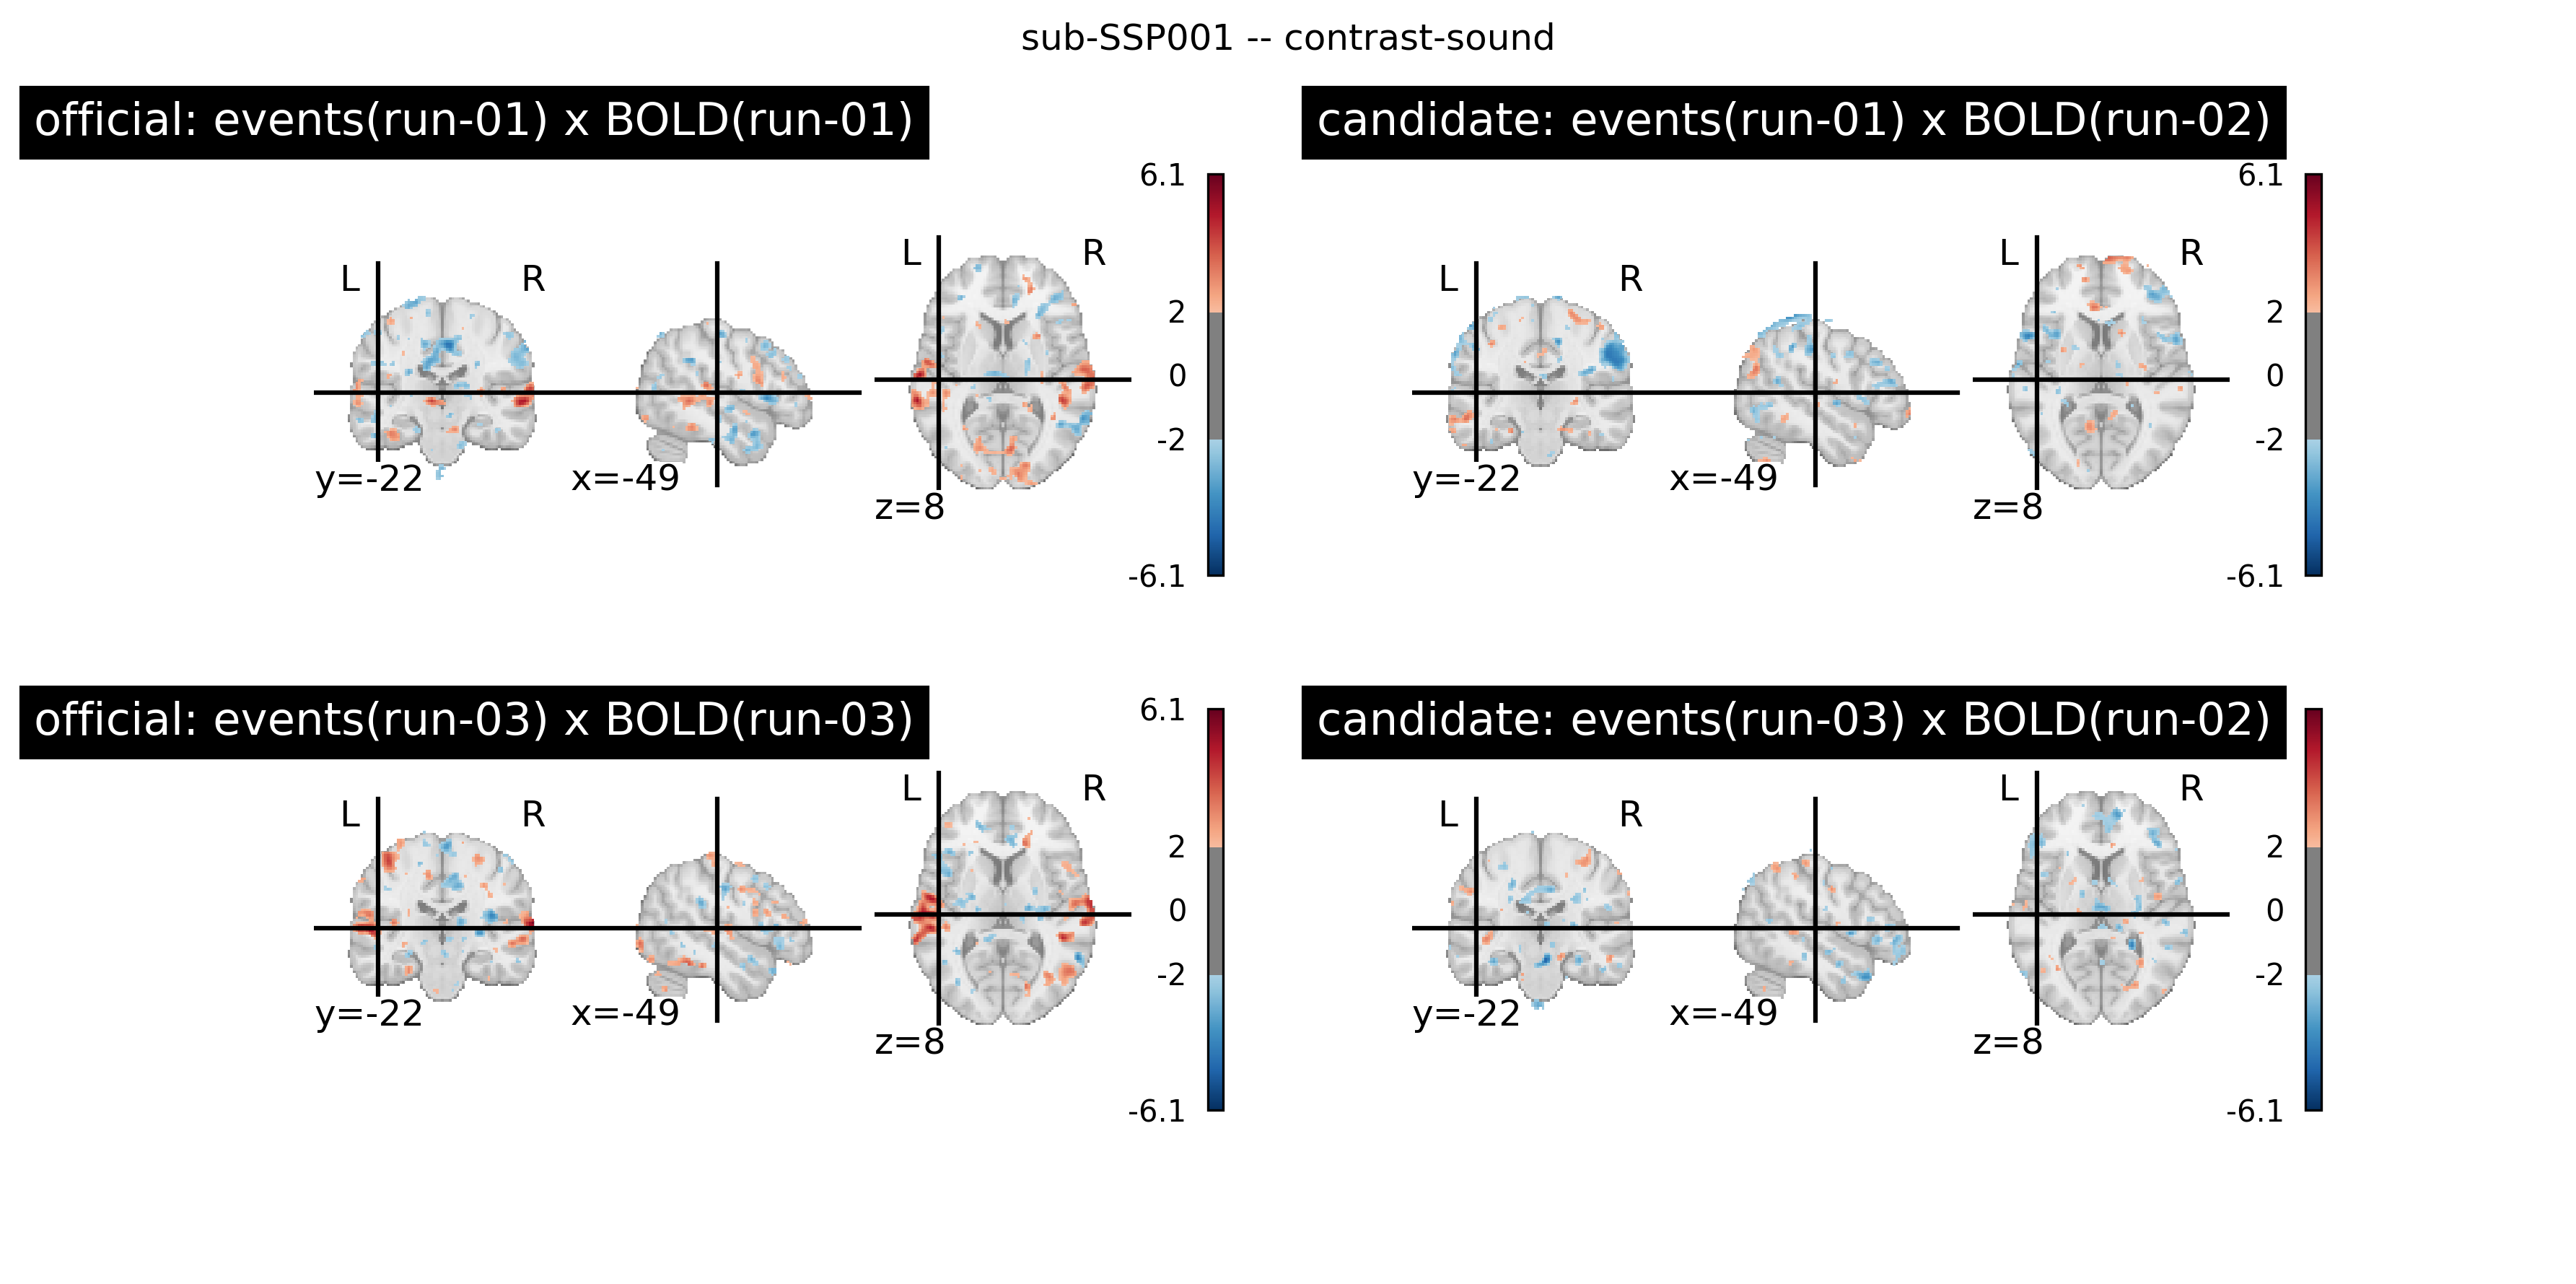

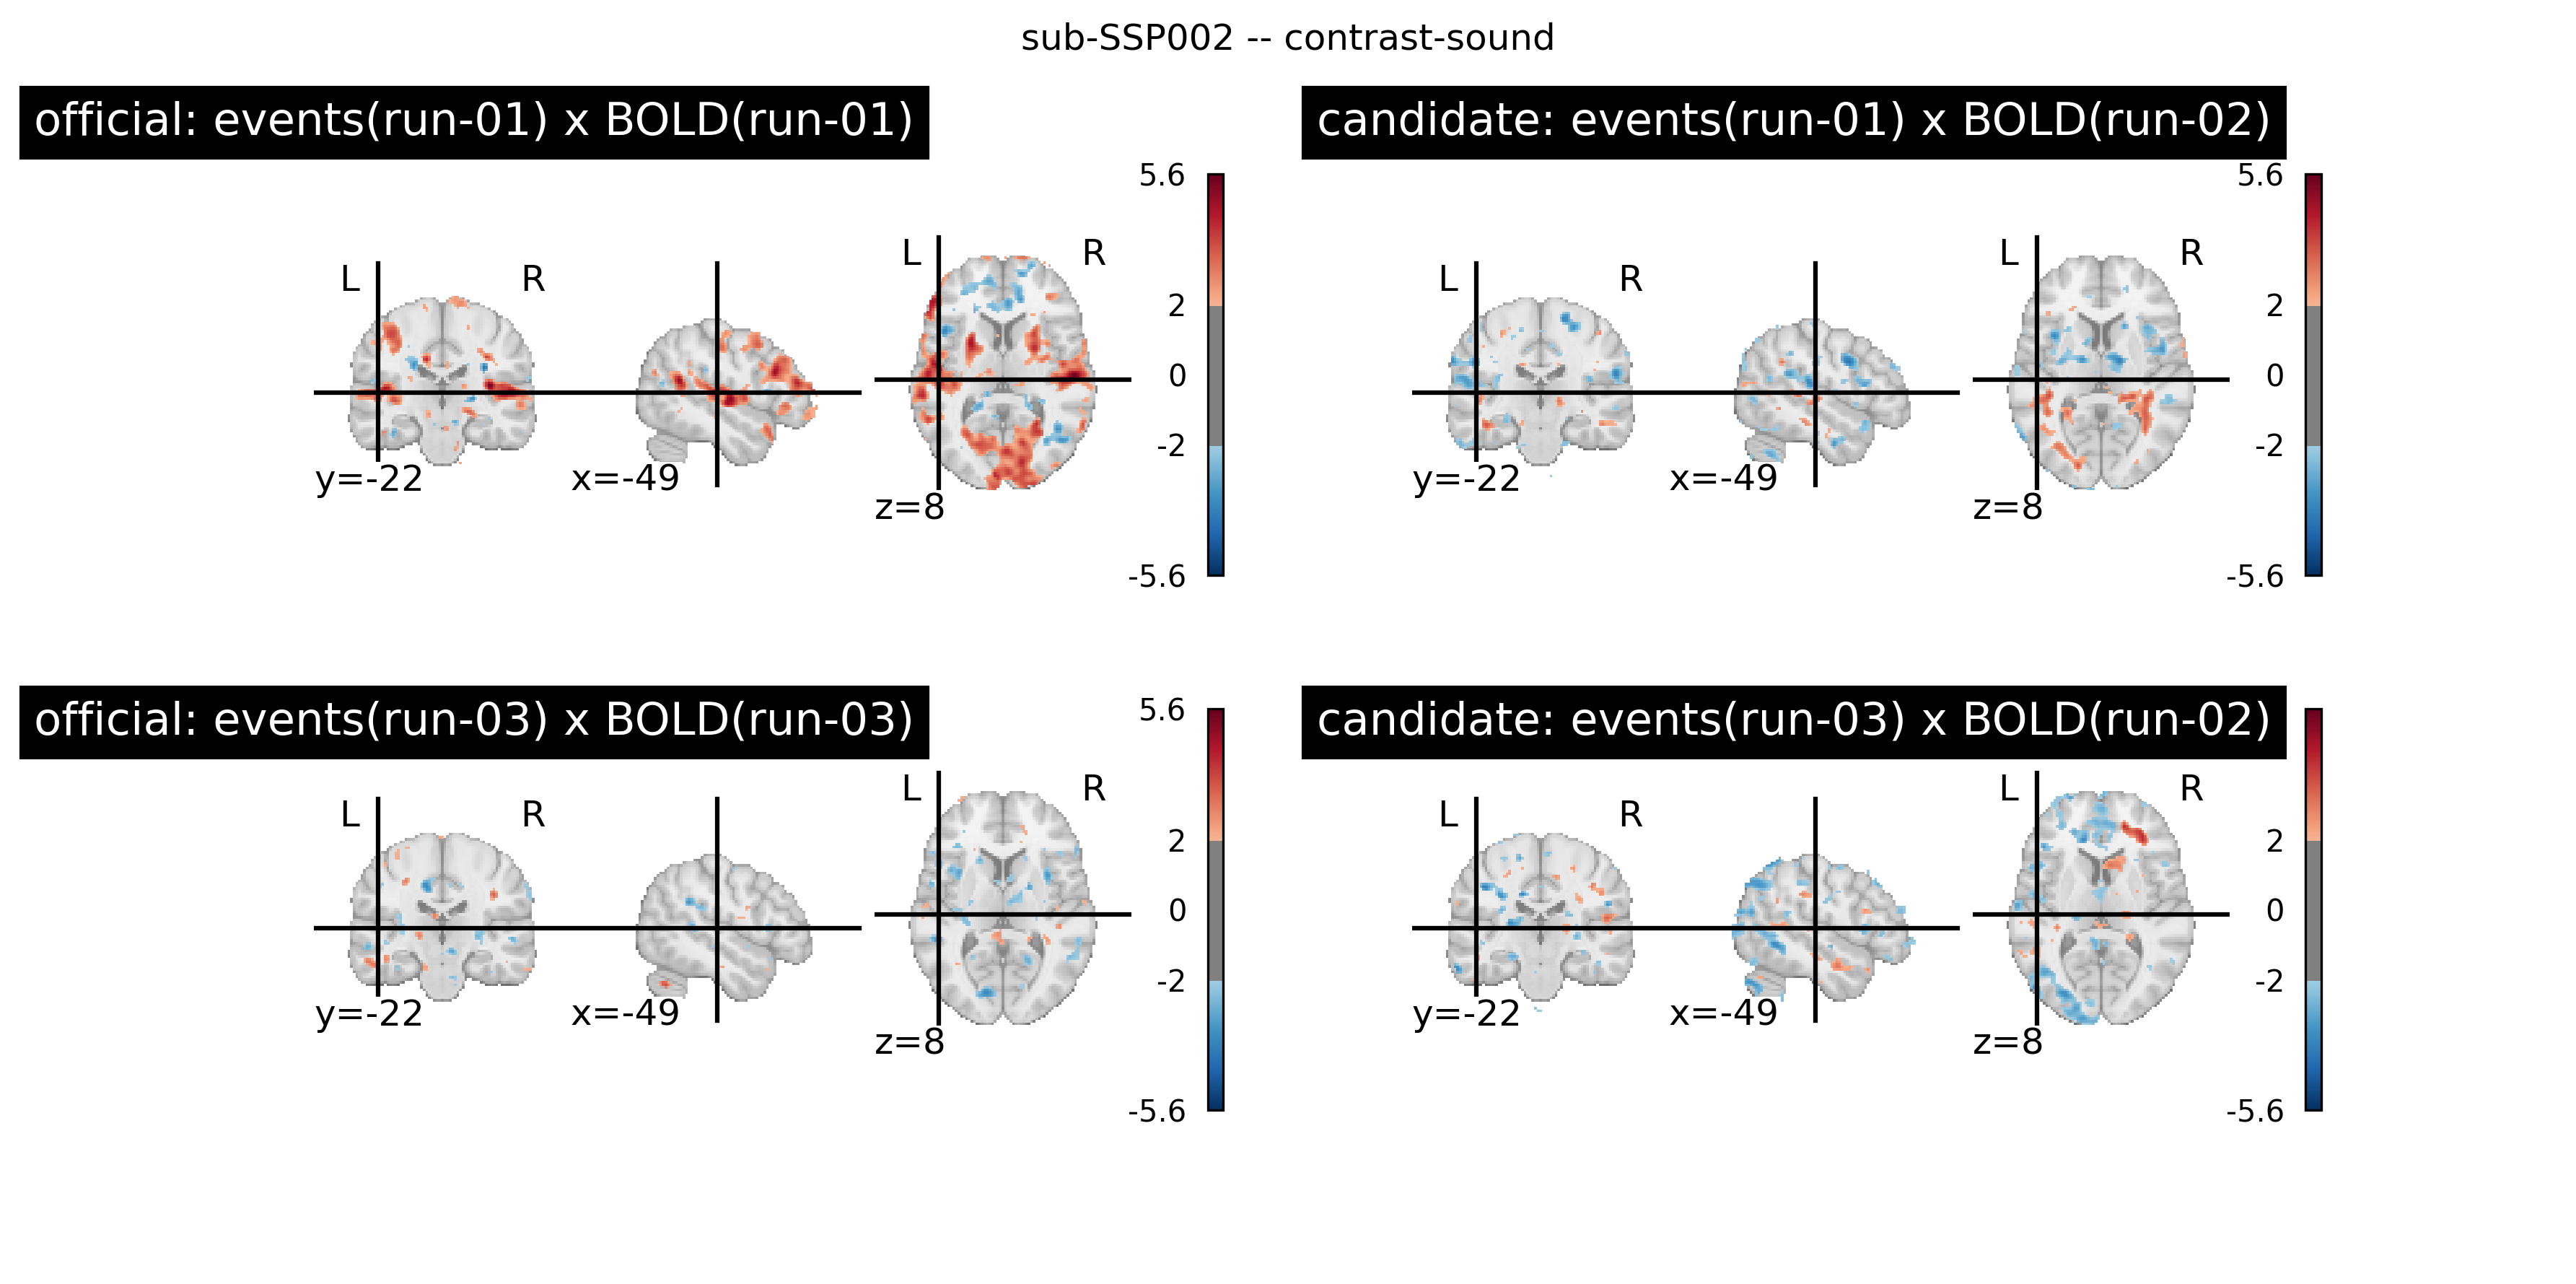

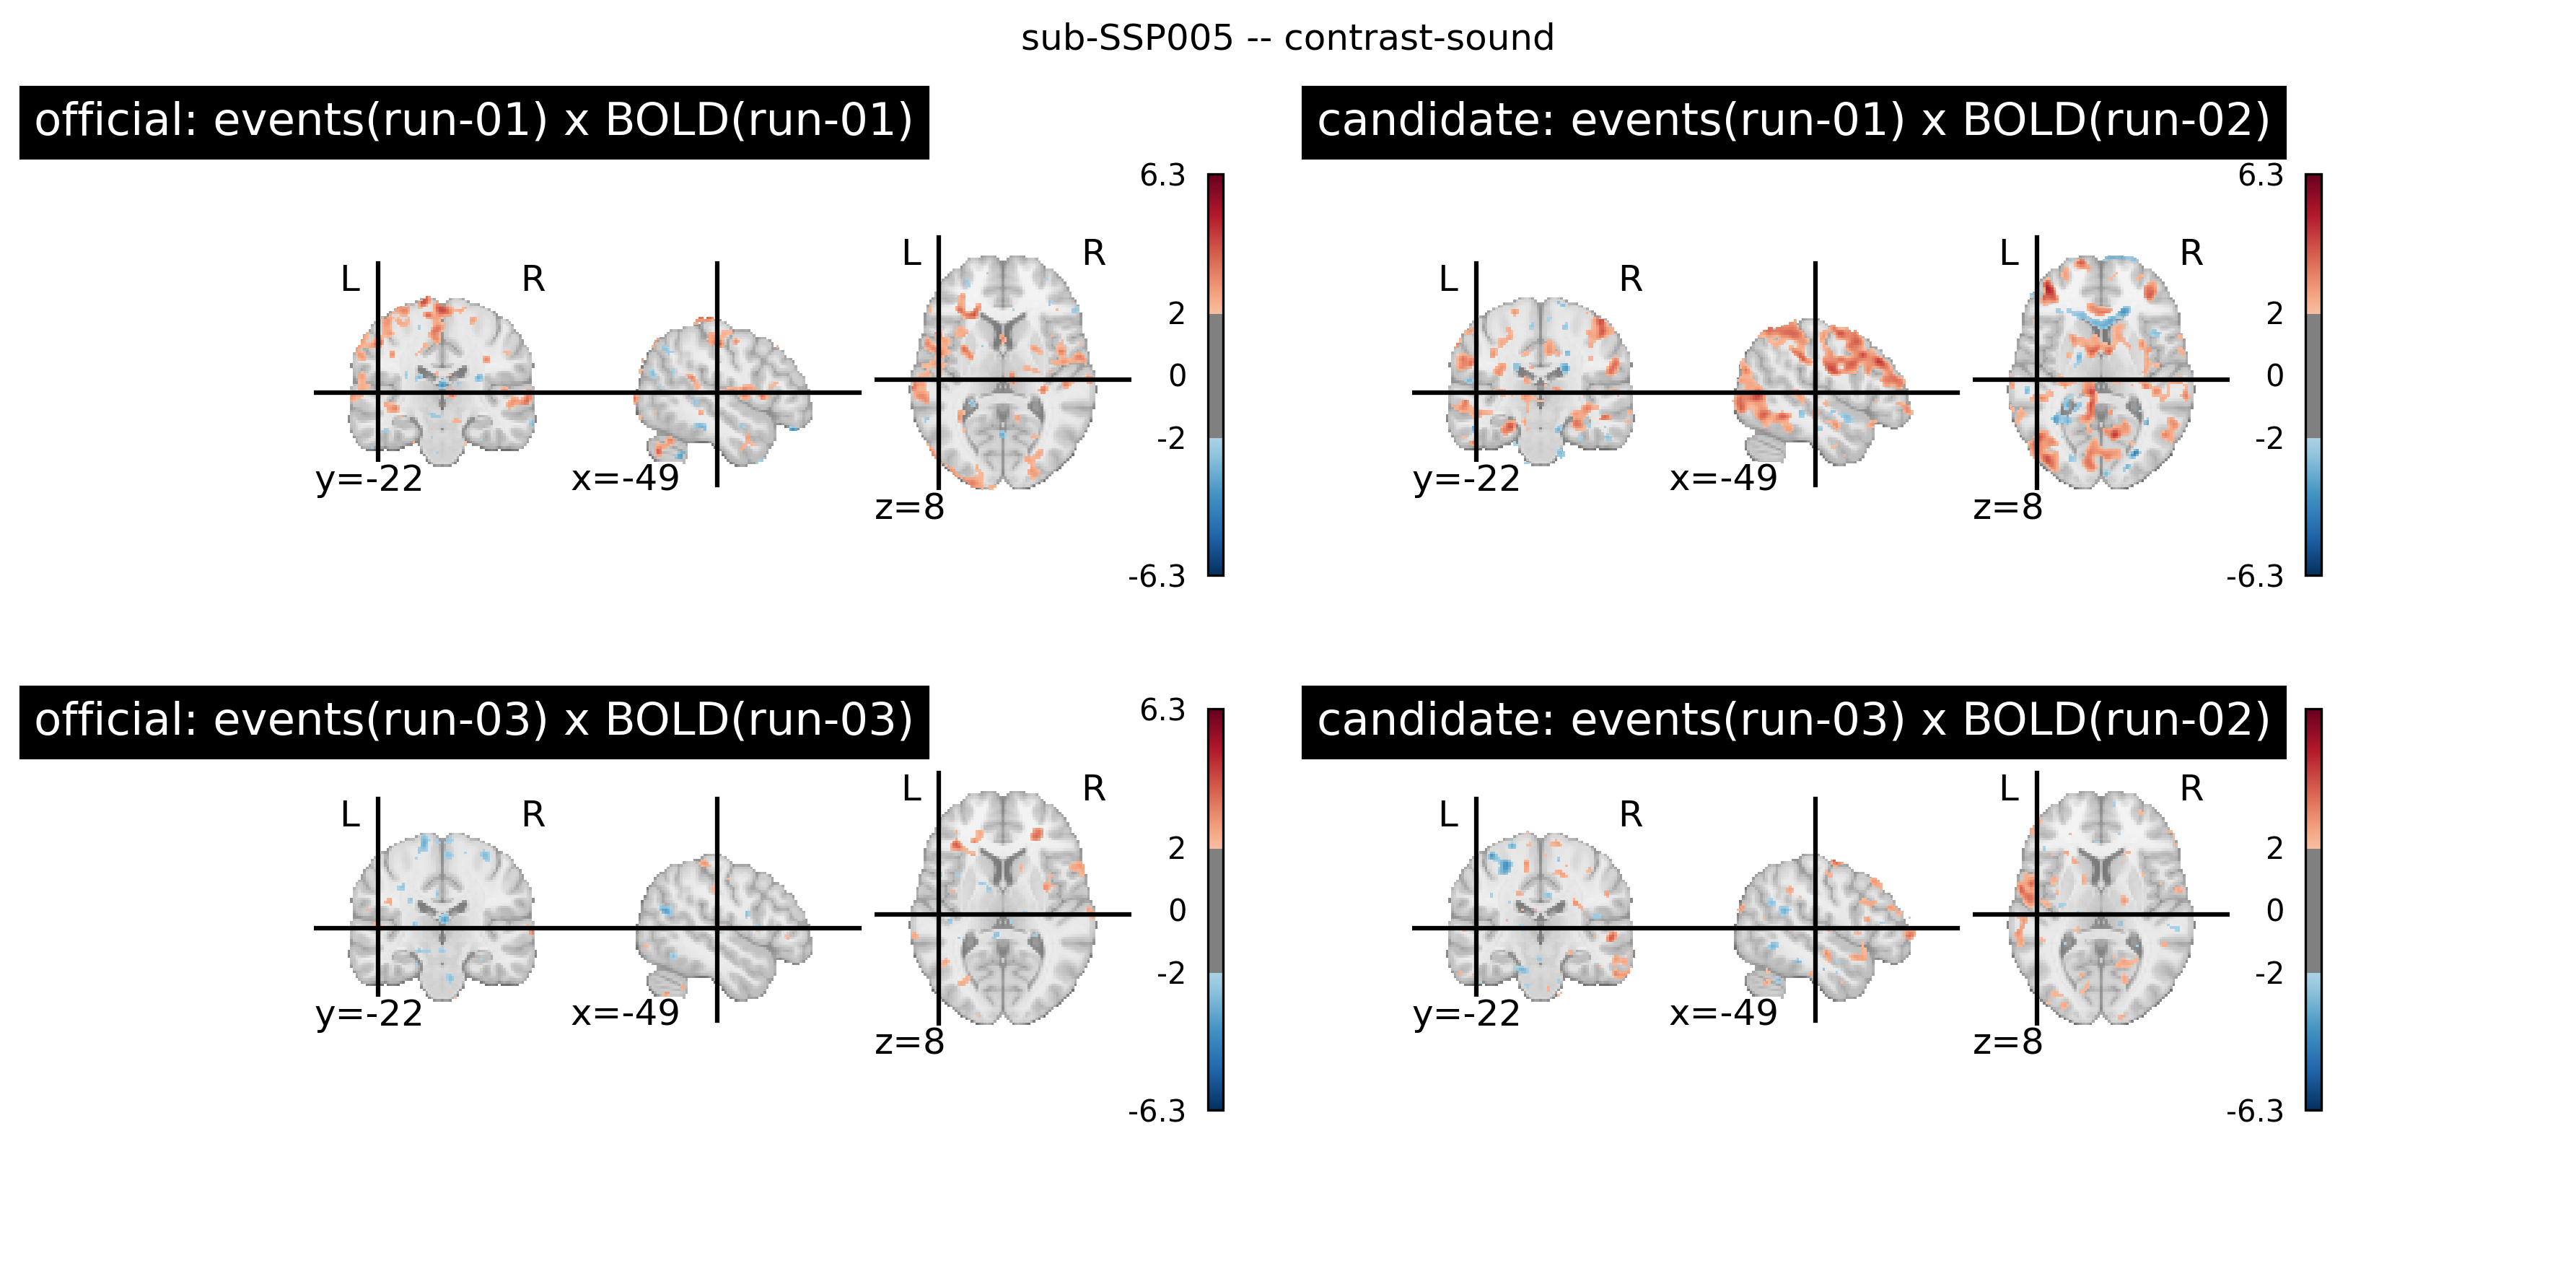

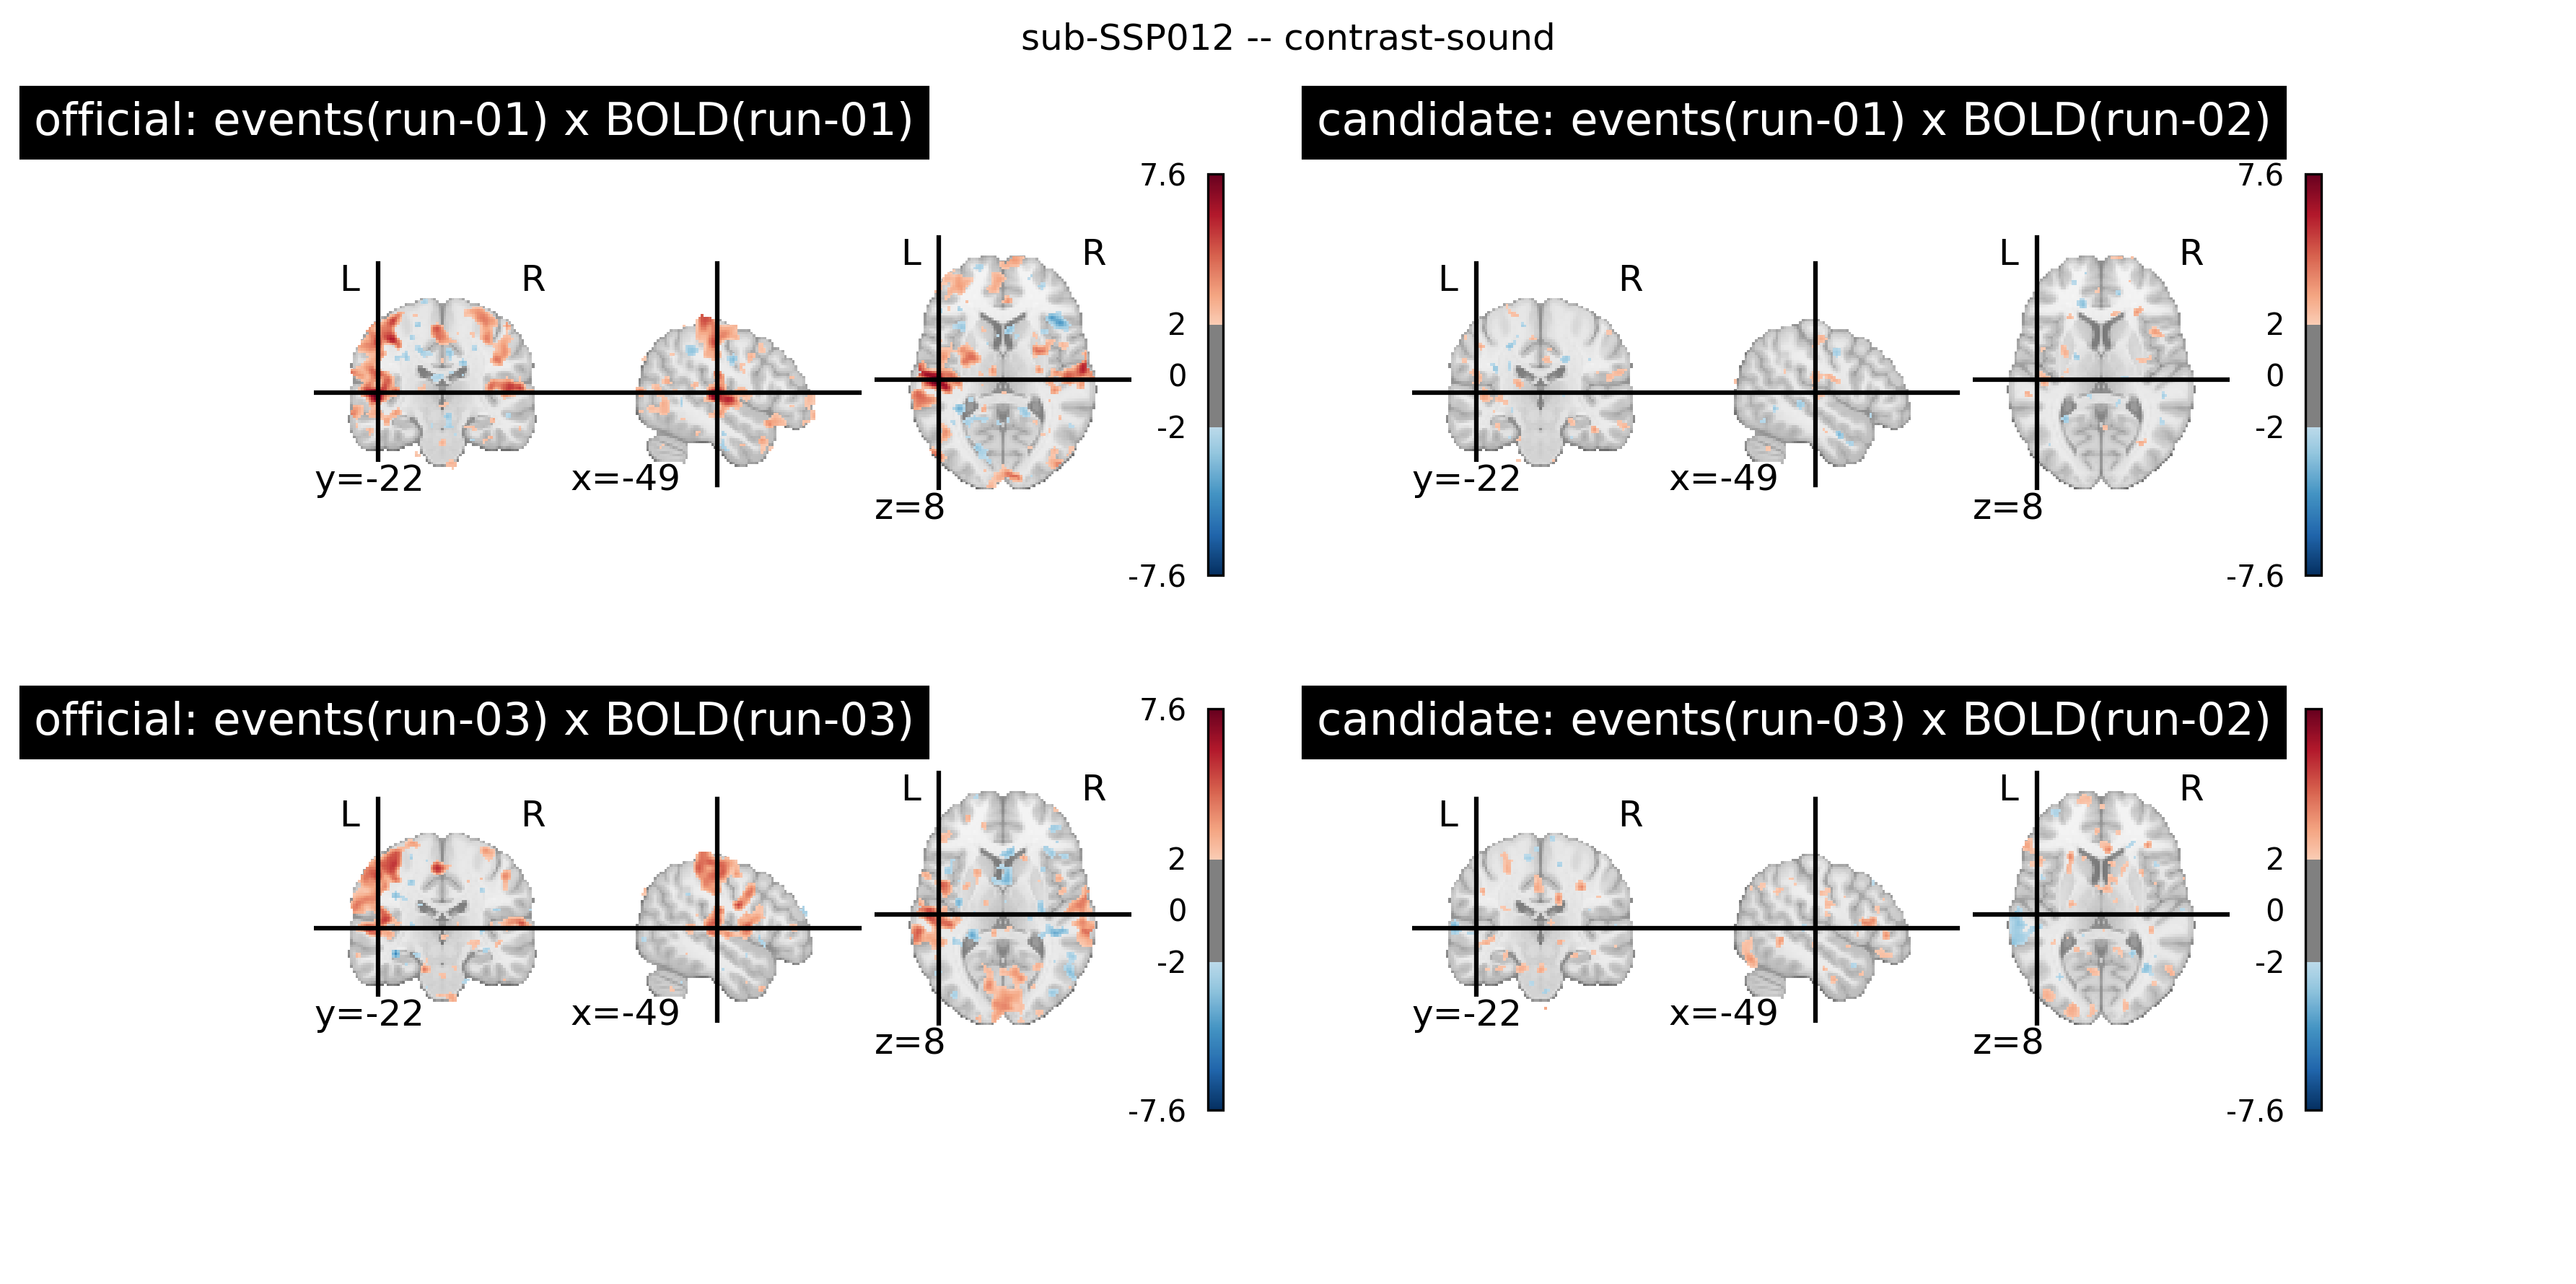

In [7]:
summary_rows = []

for sub_id, info in flagged_subs.items():
    for orphan_run in info['orphan_bold_runs']:
        print(f'\n=== {sub_id}: orphan BOLD run-{orphan_run:02d} '
             f'({info["n_volumes_by_run"].get(orphan_run)} volumes; '
             f'other runs: {({r: v for r, v in info["n_volumes_by_run"].items() if r != orphan_run})}) ===')
        fits = []

        for events_run in info['usable_event_runs']:
            try:
                official_z = fit_single_run_glm(bidsroot, fmriprep_dir, task_label, space_label,
                                                sub_id, fwhm, events_run, events_run)
                fits.append({'events_run': events_run, 'bold_run': events_run,
                            'label': 'official', 'z_maps': official_z})
            except Exception as e:
                print(f'  official fit failed for events(run-{events_run:02d}): {e}')
                continue

            try:
                candidate_z = fit_single_run_glm(bidsroot, fmriprep_dir, task_label, space_label,
                                                 sub_id, fwhm, events_run, orphan_run)
                fits.append({'events_run': events_run, 'bold_run': orphan_run,
                            'label': 'candidate', 'z_maps': candidate_z})
            except Exception as e:
                print(f'  candidate fit failed for events(run-{events_run:02d}) x '
                     f'BOLD(run-{orphan_run:02d}): {e}')
                continue

        if not fits:
            print(f'  No usable fits for {sub_id} -- skipping.')
            continue

        plot_fit_comparison(sub_id, fits, contrast_label='sound', out_dir=qa_out_dir)

        for f in fits:
            for contrast_label, z_map in f['z_maps'].items():
                stats = summarize_zmap(z_map, sub_id, AUDITORY_ROI_LIST, masks_dir, space_label)
                summary_rows.append({
                    'sub_id': sub_id, 'orphan_bold_run': orphan_run,
                    'events_run': f['events_run'], 'bold_run': f['bold_run'],
                    'pairing': f['label'], 'contrast': contrast_label,
                    **stats,
                })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(qa_out_dir, 'events_bold_alignment_qa_summary.csv'), index=False)
summary_df

## How to read this

For a genuinely mismatched pairing, the `candidate` fit (an events file tested against the
*orphan* BOLD run) should look like noise: no coherent bilateral auditory response, low peak z,
`mean_auditory_roi_z` near zero or even negative. A correctly-aligned pairing should show the
expected bilateral STG/HG response.

- If a subject's `candidate` fit looks about as strong as -- or stronger than -- its own
  `official` fits, that's real evidence the events.tsv is mislabeled, and worth a manual look at
  the raw behavioral log / scan session notes before trusting either run's data.
- If `candidate` is clearly weaker than every one of the subject's `official` fits, that supports
  the current pipeline's assumption (the orphan run's behavioral log is genuinely missing, not
  just mislabeled) -- `drop_empty_event_runs` dropping it is the right call.
- `peak_abs_z` alone can be misleading (a single hot voxel can spike it) -- weight
  `mean_auditory_roi_z` more heavily; it summarizes signal across a whole robust ROI, not one
  voxel.
- The volume counts printed above each subject's section are a cheap secondary check: an orphan
  run with a normal, full-length volume count is more suspicious (more consistent with
  mislabeling) than one that's clearly truncated (more consistent with a genuinely aborted run).

This notebook only flags and visualizes -- it does not relabel, rename, or move any file. Fix
identified mislabeling by hand (rename the actual source events.tsv), then re-run the standard
pipeline for that subject.